We import all necessary libraries:

- `pandas` and `numpy` → For data manipulation  
- `matplotlib` and `seaborn` → For visualization  
- `scikit-learn` → For machine learning (train/test split, Linear Regression, metrics)  
- `warnings` → To ignore minor warnings  

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

  Cell In[14], line 3
    We load the **California Housing Dataset** using `fetch_california_housing`.
       ^
SyntaxError: invalid syntax

## 2️⃣ Load Dataset

We load the **California Housing Dataset** using `fetch_california_housing`.  

- Features: `MedInc`, `HouseAge`, `AveRooms`, etc.  
- Target: `MedHouseVal` (median house value in hundreds of thousands of dollars)  

We convert it to a **pandas DataFrame** for easy manipulation.


In [ ]:
#  Load Dataset
from sklearn.datasets import fetch_california_housing
california = fetch_california_housing()
data = pd.DataFrame(california.data, columns=california.feature_names)
data['MedHouseVal'] = california.target  # target column


## 3️⃣ Exploratory Data Analysis (EDA)

We explore the dataset to understand the data distribution:

- `head()` → shows first 5 rows  
- `describe()` → shows summary statistics  
- Correlation heatmap → shows relationship between features and target


In [ ]:
#  Exploratory Data Analysis
print("First 5 rows:\n", data.head())
print("\nDataset Summary:\n", data.describe())

First 5 rows:
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Dataset Summary:
              MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      

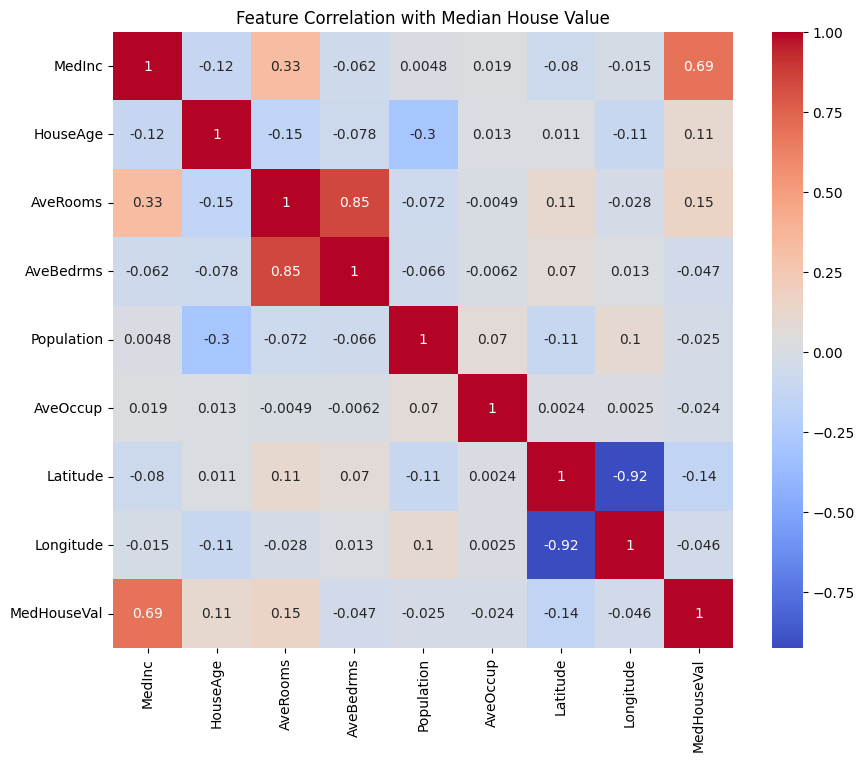

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation with Median House Value")
plt.show()

## 4️⃣ Prepare Data for Modeling

- Separate **features (X)** and **target (y)**  
- Split dataset into **training (80%)** and **testing (20%)** sets  
- `random_state=42` ensures reproducibility


In [ ]:
#  Prepare Data for Model
X = data.drop('MedHouseVal', axis=1)
y = data['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 5️⃣ Train Linear Regression Model

- We create a **LinearRegression** model  
- Train it on the **training set**  
- Predict prices for the **test set**


In [ ]:
# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## 6️⃣ Evaluate the Model

We evaluate model performance using:

- **Mean Squared Error (MSE)** → average squared difference between predicted and actual values  
- **R-squared (R²)** → how well the model explains variance in the data


In [ ]:
# Evaluate Model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.2f}")

Mean Squared Error: 0.56
R-squared Score: 0.58


## 7️⃣ Predict Example House Prices

We predict prices for **first 5 test rows** and compare with actual prices:

- `Predicted Prices` → model's prediction  
- `Actual Prices` → true values from the dataset


In [ ]:
# Predict Example House Prices
example = X_test.iloc[:5]
predicted_prices = model.predict(example)
print("\nPredicted Prices:", predicted_prices)
print("Actual Prices:   ", y_test.iloc[:5].values)



Predicted Prices: [0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]
Actual Prices:    [0.477   0.458   5.00001 2.186   2.78   ]


## 📊 Model Evaluation Using Visualizations

Numerical metrics alone do not fully explain model performance.  
To better understand how well the model predicts house prices, we use **visual evaluation techniques**.


### 🔹 1. Actual vs Predicted House Prices

This scatter plot compares **actual house prices** with **predicted house prices**.

- The dashed diagonal line represents **perfect predictions**
- Points close to the line indicate accurate predictions
- Points farther from the line indicate prediction errors

A clear diagonal pattern means the model has learned meaningful relationships from the data.

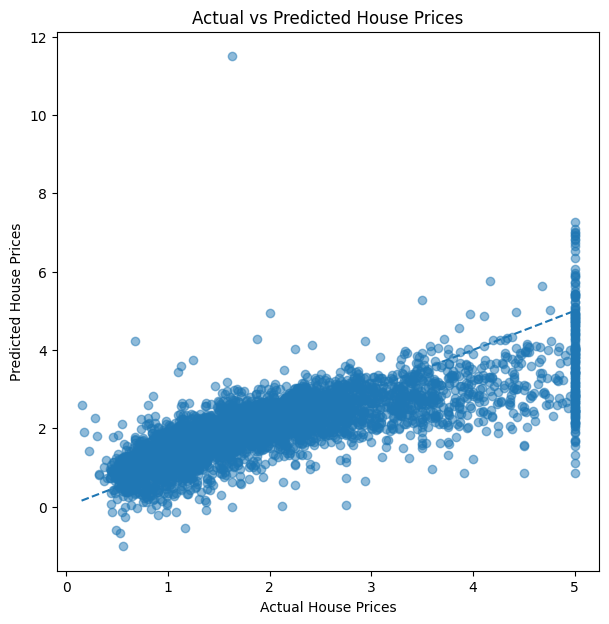

In [ ]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')
plt.xlabel("Actual House Prices")

plt.ylabel("Predicted House Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()


### 🔹 2. Residuals (Prediction Error) Distribution

Residuals are calculated as:

**Residual = Actual Price − Predicted Price**

This plot shows how prediction errors are distributed.

- Errors centered around **zero** indicate an unbiased model
- A roughly bell-shaped distribution suggests good regression behavior


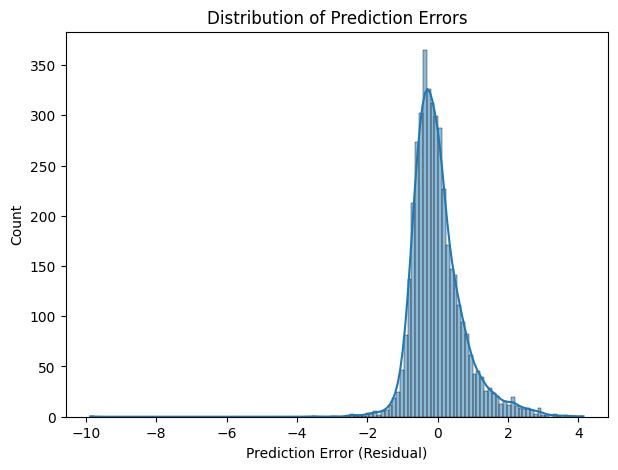

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))
sns.histplot(residuals, kde=True)
plt.xlabel("Prediction Error (Residual)")
plt.title("Distribution of Prediction Errors")
plt.show()


### 🔹 3. Feature Impact on House Prices

This bar chart visualizes the **coefficients of the Linear Regression model**.

- Positive coefficients increase house price
- Negative coefficients decrease house price
- Larger absolute values indicate stronger influence

This helps interpret **which features matter most** in predicting house prices.


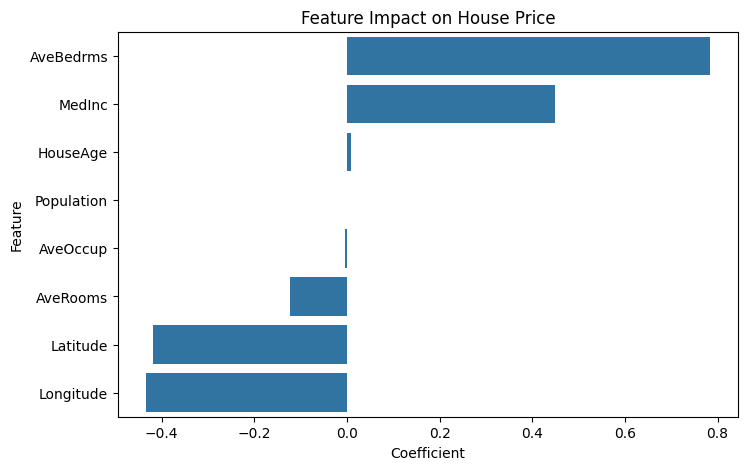

In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x="Coefficient", y="Feature", data=coefficients)
plt.title("Feature Impact on House Price")
plt.show()
